In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
llm_model = ChatGroq(
    model = 'llama-3.3-70b-versatile',
    temperature= 0
)

In [4]:
class ExpenseState(TypedDict):
    total_income : int
    total_expense : int
    curr_balance : float
    monthly_total : str

In [ ]:
def cal_total_income(state: ExpenseState):
    prompt = f"The user's total income is {state['total_income']}. Summarize this in one sentence."
    total_income = llm_model.invoke(prompt).content
    return {'total_income': state['total_income']}

def cal_total_expense(state: ExpenseState):
    prompt = f"The user's total expense is {state['total_expense']}. Summarize this in one sentence."
    total_expense = llm_model.invoke(prompt).content
    return {'total_expense': state['total_expense']}

def cal_current_balance(state: ExpenseState):
    current_balance = state['total_income'] - state['total_expense']
    return {'curr_balance': current_balance}

def cal_month_total(state: ExpenseState):
    prompt = f"The user's total monthly expense is {state['total_expense']}. Their current balance is {state['curr_balance']}. Give a short 2-line financial summary.Provide a short 2-line financial summary. If the balance is positive, call it a surplus."
    monthly_total = llm_model.invoke(prompt).content
    return {'monthly_total': monthly_total}

In [6]:
graph = StateGraph(ExpenseState)

graph.add_node('cal_total_income', cal_total_income)
graph.add_node('cal_total_expense', cal_total_expense)
graph.add_node('cal_current_balance', cal_current_balance)
graph.add_node('cal_month_total', cal_month_total)

graph.add_edge(START, 'cal_total_income')
graph.add_edge('cal_total_income', 'cal_total_expense')
graph.add_edge('cal_total_expense', 'cal_current_balance')
graph.add_edge('cal_current_balance', 'cal_month_total')
graph.add_edge('cal_month_total', END)

checkpoint = InMemorySaver()
workflow = graph.compile(checkpointer=checkpoint)

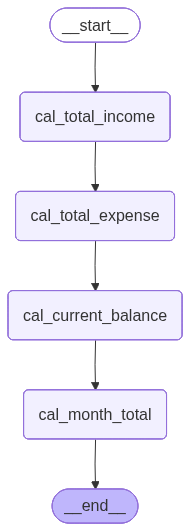

In [7]:
workflow

In [8]:
config = {'configurable' : {'thread_id' : 'user_4'}}
user_statement = {'total_income' : 25000,
     'total_expense' : 15300,
     'curr_balance' : 0,
     'monthly_total' : 0
    }

result = workflow.invoke(user_statement, config= config)['monthly_total']
print(result)

The user is currently facing a deficit of 5600, as their total monthly expense of 15300 exceeds their current balance of 9700. To achieve a surplus, the user needs to increase their balance or reduce their expenses to cover the shortfall.


In [ ]:
def get_user_input():
    print("FINANCIAL CALCULATOR")
    user_id = str(input('Enter user id to resume a conversation...'))

    if not user_id:
        return None
    
    try:
        income = int(input("Enter total income: "))
        expense = int(input("Enter total expenses: "))
        
        return user_id, {
            'total_income': income,
            'total_expense': expense,
            'curr_balance': 0,
            'monthly_total': ''
        }
    except ValueError:
        print("❌ Invalid input! Please enter numeric values to begin.")

In [10]:
def display_input_statement(result):
    print('User Statements are below:')
    print(f'Total Income: {result['total_income']:,}')
    print(f'Total Expense: {result['total_expense']:,}')
    print(f'Current Balance: {result['curr_balance']:,}')
    print(f'Monthly Total: {result['monthly_total']}')

In [ ]:
while True:
    uid, user_data = get_user_input()

# When no user-id is entered. then break.
    if not uid:
        break

# When user enters letter's instead of integars.    
    if user_data is None:
        continue
    result = workflow.invoke(user_data, config= config)
    display_input_statement(result)

    again_try = input('Do you want to try again?').strip().lower()
    if again_try not in ['yes', 'y']:
        break

FINANCIAL CALCULATOR
User Statements are below:
Total Income: 8,000
Total Expense: 3,200
Current Balance: 4,800
Monthly Total: The user has a monthly surplus of $1600, calculated by subtracting their total monthly expense from their current balance. This surplus indicates a positive financial position, with $1600 available for savings, debt repayment, or additional expenses.
